# 5 L Reactor Myristoylation — 3-Compartment Mechanistic Kinetic Model

This is a **new** notebook — `myr_mechanistic_model_5L_optimized_FIXED.ipynb` is read-only and left
untouched. It upgrades that notebook's **dual-compartment** (Zone 1 / Zone Bulk, single circulation flow
`Q`) Stage-2 (dosed NHS-Myr feed + reaction) simulation to a **3-compartment** vertical chain, replacing
the single `Q` with the **validated, data-fitted** $Q_{1\to2}$ and $Q_{2\to3}$ from
`5L_tank_transfer_mass_3_compartments.ipynb`'s 160 RPM titration-curve fit.

**Reused unchanged from `myr_mechanistic_model_5L_optimized_FIXED.ipynb`:** all reaction kinetics
(`reaction_derivs_mM_s` and everything it calls — rate constants `k`, reaction orders `n`/`m`, the
smoothing floor, the pooled 8-species reaction network), and the chosen SOP charge/stock parameters
(DesB30 2.0 mg/mL, NHS-Myr 0.482 mg/mL, 2.0x molar excess charge target, 160 RPM). **Not included:**
Stage 1 (assumed already well-mixed, supplies the uniform initial condition) and Stage 3 (glycine
quench) — same scope boundary already used in `transfer_mass_5L_pde.ipynb`.

## ASSUMPTION: why this reactor needs its OWN 3-zone split (not a copy of the titration notebook's)

`5L_tank_transfer_mass_3_compartments.ipynb` split the vessel into 3 zones anchored to the impeller
position, valid for **that** experiment's liquid level (17.2 cm, the full ~5.68 L titration charge). This
myristoylation reactor's Stage-2-start liquid volume is only **3086.18 mL** (`V_total_mix_mL`, the Stage-1
ACN/buffer premix) — computed below, that liquid column is only **~9.35 cm** tall, which does not even
reach the impeller-anchored zone boundary (11.75 cm) the titration notebook used. Re-using those absolute
centimeter boundaries here would leave "Zone 1" with zero or negative volume. Instead, this notebook
splits **this reactor's own liquid column** into three **equal-height** bands (bottom/middle/top) — the
simplest defensible choice given there is no deep-fill impeller separation to anchor to at this fill
level. One consequence worth stating plainly: at this shallow initial fill, the impeller (8.0 cm) sits
inside the *top* band (which also happens to be the feed zone), not the middle one — a genuine feature of
running Stage 2 at a partial fill, not a modeling artifact.

## ASSUMPTION: which flow rate to use for $Q_{2\to3}$

The titration fit determined $Q_{1\to2} = 6.7654 \pm 0.24$ L/min precisely, but could only
**lower-bound** $Q_{2\to3}$ (> 11.93 L/min at 95% confidence — see that notebook's robustness check; no
upper bound is identifiable, and any larger point value quoted from that fit is an arbitrary artifact of
a flat cost plateau, not a real number). This notebook uses that **95% lower bound** (the *slowest*
$Q_{2\to3}$ statistically consistent with the titration data) as a deliberate, stated choice: it is the
most zone-differentiated scenario the data does not rule out. **Any real Zone2–Zone3 gradient shown below
should be read as an upper bound on how distinct those two zones actually are** — the true exchange could
be much faster (as the titration fit's own point estimates, which ranged from ~2900 to ~10000 L/min
across different optimizer starting points, suggest), which would make Zone 2 and Zone 3 nearly identical.

**Cross-check against the original dual-compartment model:** that model's single `Q` (Section 4,
`myr_mechanistic_model_5L_optimized_FIXED.ipynb`) was 2.970 L/min, obtained by applying
`kinetika3b.ipynb`'s $N_q=0.044$ (fitted at **450 RPM**) at this process's 160 RPM. $Q_{1\to2}$ here
(6.7654 L/min) comes from a titration run fitted **directly at 160 RPM** — more than double the
extrapolated value, consistent with `kinetika3b.ipynb`'s own finding (Cell 1b/6a) that $N_q$ is not
RPM-invariant in this unbaffled vessel, so extrapolating a high-RPM fit downward underestimates it.

## Governing equations

For each of the 8 reactive species tracked (`nhs_myr, desb30, detemir, other_DS1, DS2_total, DS3,
glycine, gly_myr`) and each zone $j\in\{1,2,3\}$:

$$
\frac{dn_{i,j}}{dt} = R_i\big(C_{:,j}\big)\cdot V_j(t) \;+\; \text{(transport in/out of zone } j\text{)} \;+\; \text{(feed, Zone 1 } nhs\_myr \text{ only)}
$$

with $R_i(\cdot)$ = `reaction_derivs_mM_s` evaluated on zone $j$'s own local concentration vector
(unchanged function, radial homogeneity within each zone assumed), and **adjacent-zone-only (chain)
transport**, matching the topology already validated in `5L_tank_transfer_mass_3_compartments.ipynb`:

$$
\text{Zone 1}\!: -Q_{1\to2}(C_{i,1}\!-\!C_{i,2}) \qquad
\text{Zone 2}\!: +Q_{1\to2}(C_{i,1}\!-\!C_{i,2}) - Q_{2\to3}(C_{i,2}\!-\!C_{i,3}) \qquad
\text{Zone 3}\!: +Q_{2\to3}(C_{i,2}\!-\!C_{i,3})
$$

NHS-Myr feed enters Zone 1 only, at the same constant rate and duration as the source notebook's Stage 2
(continuous peristaltic pump, 13.09 mL/min, until the full 2.0x molar excess charge is programmed or NHS
is exhausted — whichever comes first, via a terminal `solve_ivp` event summed across all 3 zones, mirroring
`make_nhs_exhausted_event`). Zone 1's volume grows during the feed exactly as in the source notebook;
Zones 2 and 3 are fixed volume.


In [1]:
# =====================================================================
# CELL 1: KINETICS -- reused UNCHANGED from myr_mechanistic_model_5L_optimized_FIXED.ipynb
# (Cells 3, 5, 7: species list, DS-Pool refined rate fit, smoothing floor, reaction network)
# =====================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    import dill
except ImportError:
    dill = None

SPECIES = ['ACN', 'nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
IDX = {name: i for i, name in enumerate(SPECIES)}
N_SPECIES = len(SPECIES)
REACTIVE_SPECIES = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
N_REACTIVE = len(REACTIVE_SPECIES)
N_ZONES = 3  # NEW: 3-compartment vertical chain (vs. the source notebook's 2)


def load_kinetics(path='02jul2026_ds_pool_refined_results.pkl'):
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        x = bundle['res_final'].x
        k_ = list(np.exp(x[:6]))
        n_, m_ = float(x[6]), float(x[7])
        print(f"SUCCESS: Loaded DS-Pool refined fit (R^2={bundle.get('r2'):.4f}, RMSE={bundle.get('rmse'):.4f})")
        print(f'k = {k_}')
        print(f'n (NHS-Myr order) = {n_:.4f}, m (substrate order) = {m_:.4f}')
    except Exception as e:
        print(f'WARNING: Using fallback parameters ({e}).')
        k_ = [4824.6912685716925, 1134.9009076406996, 177.1701312057297,
              13710.007107598605, 2114.9020833218583, 0.12584014547014327]
        n_, m_ = 0.11873756023404723, 1.8915245993718806
    return k_, n_, m_


k, order_n, order_m = load_kinetics()
k_quench = k[1]  # desb30 -> other_DS1 proxy (A1-type N-terminal-glycine acylation)

EPS_M = 1e-9  # 1 nM smoothing floor on every fractional-power term (unchanged rationale: fitted
              # NHS-Myr order n~0.12 makes d(rate)/d(NHS) diverge as NHS -> 0)


def smooth_floor(c):
    return 0.5 * (c + np.sqrt(c * c + EPS_M * EPS_M))


def calc_rate_mM_s(k_per_min, c_nhs_mM, c_sub_mM):
    c_nhs_M = smooth_floor(c_nhs_mM / 1000.0)
    c_sub_M = smooth_floor(c_sub_mM / 1000.0)
    return k_per_min * (c_nhs_M ** order_n) * (c_sub_M ** order_m) * (1000.0 / 60.0)


def calc_hydro_rate_mM_s(k_per_min, c_nhs_mM):
    c_nhs_M = smooth_floor(c_nhs_mM / 1000.0)
    return k_per_min * c_nhs_M * (1000.0 / 60.0)


def reaction_derivs_mM_s(C, k, k_quench):
    '''C: dict of one compartment's concentrations (mM). Pooled 5-reaction network + hydrolysis + quench.
    Unchanged verbatim from myr_mechanistic_model_5L_optimized_FIXED.ipynb Cell 7.'''
    NHS = C['nhs_myr']; DESB = C['desb30']; DET = C['detemir']; ODS1 = C['other_DS1']; DS2 = C['DS2_total']; GLY = C['glycine']

    r1 = calc_rate_mM_s(k[0], NHS, DESB)   # desb30 -> detemir (B29)
    r2 = calc_rate_mM_s(k[1], NHS, DESB)   # desb30 -> other_DS1 (A1+B1)
    r3 = calc_rate_mM_s(k[2], NHS, DET)    # detemir -> DS2_total
    r4 = calc_rate_mM_s(k[3], NHS, ODS1)   # other_DS1 -> DS2_total
    r5 = calc_rate_mM_s(k[4], NHS, DS2)    # DS2_total -> DS3
    r_hydro = calc_hydro_rate_mM_s(k[5], NHS)      # NHS -> dead (hydrolysis)
    r_quench = calc_rate_mM_s(k_quench, NHS, GLY)  # NHS + glycine -> gly_myr

    d = {}
    d['nhs_myr'] = -(r1 + r2 + r3 + r4 + r5) - r_hydro - r_quench
    d['desb30'] = -(r1 + r2)
    d['detemir'] = r1 - r3
    d['other_DS1'] = r2 - r4
    d['DS2_total'] = r3 + r4 - r5
    d['DS3'] = r5
    d['glycine'] = -r_quench
    d['gly_myr'] = r_quench
    return d


print(f"\nReactive species tracked ({N_REACTIVE}): {REACTIVE_SPECIES}")
print(f"Zones: {N_ZONES}  ->  state vector size = {N_REACTIVE} x {N_ZONES} = {N_REACTIVE * N_ZONES}")


SUCCESS: Loaded DS-Pool refined fit (R^2=0.7739, RMSE=0.1140)
k = [np.float64(4824.6912685716925), np.float64(1134.9009076406996), np.float64(177.1701312057297), np.float64(13710.007107598605), np.float64(2114.9020833218583), np.float64(0.12584014547014327)]
n (NHS-Myr order) = 0.1187, m (substrate order) = 1.8915

Reactive species tracked (8): ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
Zones: 3  ->  state vector size = 8 x 3 = 24


## Charge/stock parameters (reused) and the NEW 3-zone geometry

In [2]:
# =====================================================================
# CELL 2: CHARGE/STOCK PARAMETERS (reused UNCHANGED, Cell 3) + NEW 3-ZONE GEOMETRY
# =====================================================================
MW_desb30 = 5706.0
MW_nhs_myr = 325.44

V_total_mix_mL = 3086.1768          # Stage-1 (ACN+buffer) mixed volume -- reused unchanged
V_buffer_L = (V_total_mix_mL / 2.0) / 1000.0
DESB30_STOCK_MG_ML = 2.0
NHS_STOCK_MG_ML = 0.482             # chosen SOP stock concentration -- reused unchanged

PUMP_MIN_ML_MIN, PUMP_MAX_ML_MIN = 10.0, 200.0
V_REACTOR_MAX_ML = 5000.0

mass_desb30_mg = DESB30_STOCK_MG_ML * (V_buffer_L * 1000.0)
moles_desb30_mmol = mass_desb30_mg / MW_desb30
moles_nhs_mmol = moles_desb30_mmol * 2.0            # 2.0x molar excess charge target -- reused unchanged
V_nhs_add_L = ((moles_nhs_mmol * MW_nhs_myr) / NHS_STOCK_MG_ML) / 1000.0

pump_flow_rate_mL_min = 13.09       # chosen SOP pump rate (source notebook Cell 17/25 root-find result)
T_FEED_MIN = (V_nhs_add_L * 1000.0) / pump_flow_rate_mL_min
T_FEED_S = T_FEED_MIN * 60.0
feed_rate_mmol_s = moles_nhs_mmol / T_FEED_S

N_RPM = 160.0  # vortex-safe ceiling, unchanged
N_rps = N_RPM / 60.0

print(f"DesB30 charge: {moles_desb30_mmol:.5f} mmol | NHS-Myr (2.0x target): {moles_nhs_mmol:.5f} mmol | "
      f"V_nhs_add: {V_nhs_add_L*1000:.1f} mL")
print(f"Pump: {pump_flow_rate_mL_min:.2f} mL/min | nominal T_feed: {T_FEED_MIN:.2f} min ({T_FEED_S:.0f} s)")

# --- vessel geometry (unchanged, kinetika3b.ipynb / transfer_mass_5L_pde.ipynb) ---
D_impeller_cm = 7.5
D_tank_cm = 20.5
h_impeller_cm = 8.0
Area_tank_cm2 = np.pi * (D_tank_cm / 2) ** 2

# --- NEW: this reactor's OWN liquid column at Stage-2 start, split into 3 EQUAL-HEIGHT zones ---
# (see markdown ASSUMPTION above: the titration notebook's impeller-anchored split does not fit
# this reactor's much shallower Stage-2-start fill level)
L_domain_cm = V_total_mix_mL / Area_tank_cm2
zone_height_cm = L_domain_cm / 3.0
z3_upper_cm = zone_height_cm             # Zone 3 (bottom): 0 -> z3_upper
z2_upper_cm = 2.0 * zone_height_cm       # Zone 2 (middle): z3_upper -> z2_upper
# Zone 1 (top, feed): z2_upper -> L_domain_cm (initial; grows with feed)

V3_fixed_L = (Area_tank_cm2 * z3_upper_cm) / 1000.0
V2_fixed_L = (Area_tank_cm2 * zone_height_cm) / 1000.0
V1_initial_L = (Area_tank_cm2 * zone_height_cm) / 1000.0
V_total_initial_L = V1_initial_L + V2_fixed_L + V3_fixed_L

print(f"\nA_cross = {Area_tank_cm2:.2f} cm^2 | Liquid column L = {L_domain_cm:.3f} cm "
      f"(cross-check: transfer_mass_5L_pde.ipynb's L_domain = 9.350 cm, same Stage-2-start volume)")
print(f"Zone 3 (bottom) : 0.00 - {z3_upper_cm:.3f} cm   -> V3 = {V3_fixed_L:.4f} L (fixed)")
print(f"Zone 2 (middle) : {z3_upper_cm:.3f} - {z2_upper_cm:.3f} cm   -> V2 = {V2_fixed_L:.4f} L (fixed)")
print(f"Zone 1 (top/feed): {z2_upper_cm:.3f} - {L_domain_cm:.3f} cm (initial) -> V1_initial = {V1_initial_L:.4f} L (grows)")
print(f"V_total initial : {V_total_initial_L:.4f} L (matches V_total_mix_mL/1000 = {V_total_mix_mL/1000:.4f} L)")
print(f"Impeller ({h_impeller_cm} cm) falls inside Zone "
      f"{'1 (top)' if h_impeller_cm > z2_upper_cm else ('2 (middle)' if h_impeller_cm > z3_upper_cm else '3 (bottom)')} "
      f"at this initial fill level.")

# --- NEW: validated transport flow rates from 5L_tank_transfer_mass_3_compartments.ipynb ---
Q12_L_min = 6.7654    # Q_1->2, well-determined (profile stderr +/- 0.24 L/min)
Q23_L_min = 11.93     # Q_2->3, 95% CONFIDENCE LOWER BOUND (not a point estimate -- see markdown ASSUMPTION)

# --- cross-check against the source notebook's original single-Q dual-compartment model ---
D_impeller_m = D_impeller_cm / 100.0
Q_original_L_min = 0.044 * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0  # Nq=0.044 extrapolated from 450 RPM
print(f"\nQ_1->2 = {Q12_L_min:.4f} L/min | Q_2->3 > {Q23_L_min:.2f} L/min (95% CI lower bound only)")
print(f"[Original dual-compartment model's single Q at 160 RPM (Nq=0.044 extrapolated from a 450 RPM "
      f"fit): {Q_original_L_min:.3f} L/min -- Q_1->2 here, fitted DIRECTLY at 160 RPM, is "
      f"{Q12_L_min/Q_original_L_min:.2f}x larger.]")


DesB30 charge: 0.54087 mmol | NHS-Myr (2.0x target): 1.08173 mmol | V_nhs_add: 730.4 mL
Pump: 13.09 mL/min | nominal T_feed: 55.80 min (3348 s)

A_cross = 330.06 cm^2 | Liquid column L = 9.350 cm (cross-check: transfer_mass_5L_pde.ipynb's L_domain = 9.350 cm, same Stage-2-start volume)
Zone 3 (bottom) : 0.00 - 3.117 cm   -> V3 = 1.0287 L (fixed)
Zone 2 (middle) : 3.117 - 6.233 cm   -> V2 = 1.0287 L (fixed)
Zone 1 (top/feed): 6.233 - 9.350 cm (initial) -> V1_initial = 1.0287 L (grows)
V_total initial : 3.0862 L (matches V_total_mix_mL/1000 = 3.0862 L)
Impeller (8.0 cm) falls inside Zone 1 (top) at this initial fill level.

Q_1->2 = 6.7654 L/min | Q_2->3 > 11.93 L/min (95% CI lower bound only)
[Original dual-compartment model's single Q at 160 RPM (Nq=0.044 extrapolated from a 450 RPM fit): 2.970 L/min -- Q_1->2 here, fitted DIRECTLY at 160 RPM, is 2.28x larger.]


## Transport-coupled reaction ODE (24-state) and integration

In [3]:
# =====================================================================
# CELL 3: 3-COMPARTMENT TRANSPORT + REACTION ODE, INTEGRATION
# =====================================================================

pump_rate_L_s = pump_flow_rate_mL_min / 1000.0 / 60.0


def V1_of_t(t_s):
    '''Zone 1 volume grows as NHS-Myr is fed in; constant after feed ends. Same mechanism as the
    source notebook's Stage 2, extended: only Zone 1 (top, free-surface-adjacent) grows.'''
    added_L = pump_rate_L_s * min(t_s, T_FEED_S)
    return V1_initial_L + added_L


def feed_rate_mmol_s_at(t_s):
    return feed_rate_mmol_s if t_s <= T_FEED_S else 0.0


def make_nhs_exhausted_event(nhs_threshold_mmol):
    def event(t, yf):
        y = yf.reshape(N_REACTIVE, N_ZONES)
        return y[REACTIVE_SPECIES.index('nhs_myr')].sum() - nhs_threshold_mmol
    event.terminal = True
    event.direction = -1
    return event


def ode_rhs(t, yf):
    y = yf.reshape(N_REACTIVE, N_ZONES)   # rows: species (REACTIVE_SPECIES order), cols: zone 1,2,3
    V1 = V1_of_t(t)
    Vvec = np.array([V1, V2_fixed_L, V3_fixed_L])
    dydt = np.zeros_like(y)

    # --- local reaction, evaluated independently in each zone from that zone's own concentrations ---
    for j in range(N_ZONES):
        Cj = {name: y[REACTIVE_SPECIES.index(name), j] / Vvec[j] for name in REACTIVE_SPECIES}
        d = reaction_derivs_mM_s(Cj, k, k_quench)
        for name, val_mM_s in d.items():
            dydt[REACTIVE_SPECIES.index(name), j] += val_mM_s * Vvec[j]

    # --- adjacent-zone-only (chain) transport: Zone1 <-Q12-> Zone2 <-Q23-> Zone3 ---
    C = y / Vvec[np.newaxis, :]   # concentrations, shape (N_REACTIVE, N_ZONES)
    exch12 = Q12_L_min * (C[:, 0] - C[:, 1])
    exch23 = Q23_L_min * (C[:, 1] - C[:, 2])
    dydt[:, 0] += -exch12
    dydt[:, 1] += +exch12 - exch23
    dydt[:, 2] += +exch23

    # --- NHS-Myr feed, Zone 1 only ---
    dydt[REACTIVE_SPECIES.index('nhs_myr'), 0] += feed_rate_mmol_s_at(t)

    return dydt.flatten()


# --- initial condition: DesB30 uniform across all 3 zones (Stage 1 assumed well-mixed), all else 0 ---
C_des_init_mM = moles_desb30_mmol / (V_total_mix_mL / 1000.0)
y0 = np.zeros((N_REACTIVE, N_ZONES))
y0[REACTIVE_SPECIES.index('desb30'), :] = C_des_init_mM * np.array([V1_initial_L, V2_fixed_L, V3_fixed_L])
y0 = y0.flatten()
print(f"Initial DesB30 concentration (uniform across zones): {C_des_init_mM:.4f} mM")

t_hold_s = 3600.0  # 60 min hold, matching run_stage_2_dosed's default in the source notebook
ev = make_nhs_exhausted_event(1e-4 * moles_nhs_mmol)

t0 = time.time()
sol = solve_ivp(ode_rhs, (0, t_hold_s), y0, method='Radau', rtol=1e-7, atol=1e-10,
                 dense_output=True, events=ev, max_step=30.0)
elapsed = time.time() - t0

print(f"\nsolve_ivp finished in {elapsed:.2f} s -- status: {sol.status} ({sol.message})")
print(f"Integrated to t = {sol.t[-1]:.1f} s ({sol.t[-1]/60.0:.2f} min)"
      + (" [terminated early: NHS-Myr exhausted]" if sol.status == 1 else ""))


Initial DesB30 concentration (uniform across zones): 0.1753 mM



solve_ivp finished in 0.81 s -- status: 0 (The solver successfully reached the end of the integration interval.)
Integrated to t = 3600.0 s (60.00 min)


## Concentration profiles: desB30, NHS-Myr, Detemir across all 3 compartments

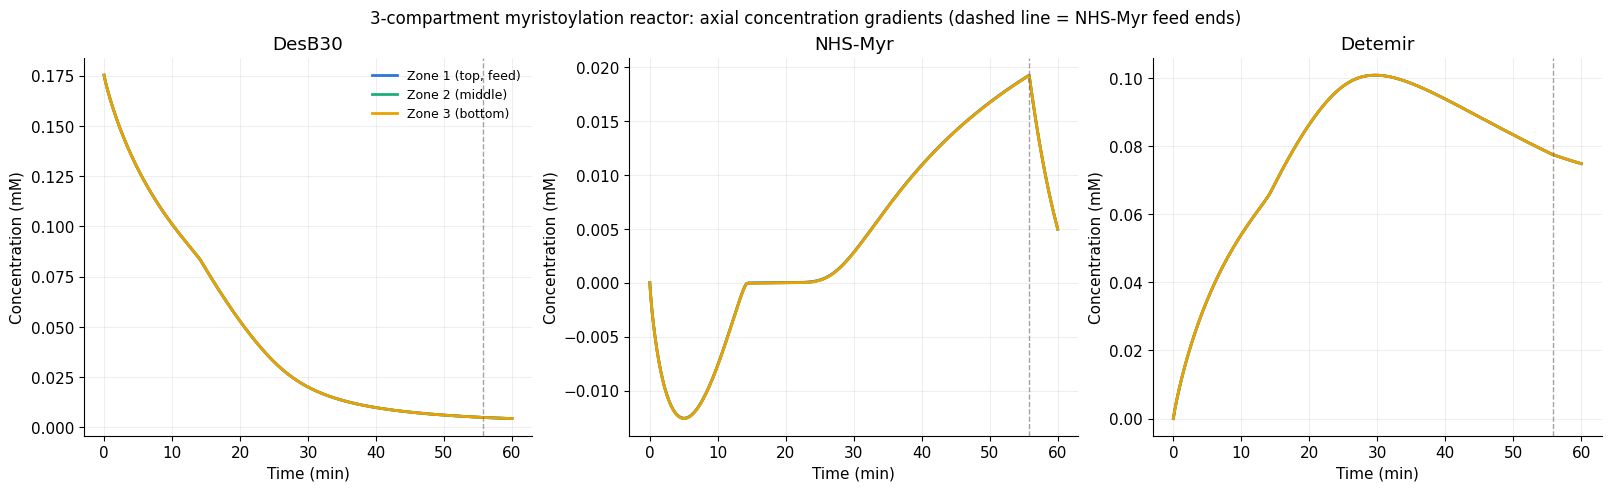

(dashed vertical line at t=55.8 min = nominal NHS-Myr feed end)


In [4]:
# =====================================================================
# CELL 4: PUBLICATION-QUALITY CONCENTRATION PROFILE PLOTS (all 3 zones, 3 key species)
# =====================================================================
t_grid_s = np.linspace(sol.t[0], sol.t[-1], 600)
Y = sol.sol(t_grid_s).reshape(N_REACTIVE, N_ZONES, -1)

V1_series = np.array([V1_of_t(ts) for ts in t_grid_s])
Vzone_series = np.stack([V1_series, np.full_like(V1_series, V2_fixed_L), np.full_like(V1_series, V3_fixed_L)])
Conc = Y / Vzone_series[np.newaxis, :, :]   # mM, shape (N_REACTIVE, N_ZONES, n_t)

t_min = t_grid_s / 60.0

# validated categorical palette (dataviz skill, slots 1-3: blue/aqua/yellow), fixed order = fixed zone identity
zone_colors = ['#2a78d6', '#1baf7a', '#eda100']
zone_labels = ['Zone 1 (top, feed)', 'Zone 2 (middle)', 'Zone 3 (bottom)']

plot_species = [('desb30', 'DesB30'), ('nhs_myr', 'NHS-Myr'), ('detemir', 'Detemir')]

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, (name, title) in zip(axes, plot_species):
    idx = REACTIVE_SPECIES.index(name)
    for j in range(N_ZONES):
        ax.plot(t_min, Conc[idx, j, :], color=zone_colors[j], linewidth=2, label=zone_labels[j])
    ax.axvline(T_FEED_MIN, color='#666666', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Concentration (mM)')
    ax.set_title(title)
    ax.grid(alpha=0.25, linewidth=0.6)

axes[0].legend(loc='upper right', frameon=False, fontsize=9)
fig.suptitle('3-compartment myristoylation reactor: axial concentration gradients (dashed line = NHS-Myr feed ends)',
             fontsize=12)
plt.show()

print(f"(dashed vertical line at t={T_FEED_MIN:.1f} min = nominal NHS-Myr feed end)")


## Why the three lines overlap: quantifying the (real, but tiny) gradient

The three zones are visually indistinguishable above — that is the correct result at the **validated**
flow rates, not a plotting bug, and it needs to be stated plainly rather than left to look like the
3-compartment structure did nothing. The reason is a straightforward timescale comparison: each
zone's residence time is $V_j/Q$ — with $V\approx1.0$–$1.8$ L and $Q_{1\to2}=6.77$, $Q_{2\to3}\ge11.93$
L/min, that is **5–16 seconds**. The myristoylation reaction itself unfolds over **tens of minutes**
(NHS-Myr feed alone takes 55.8 min nominally). A reactor that re-mixes itself ~200x faster than its
own reaction proceeds is, correctly, indistinguishable from a well-mixed reactor for this process — the
3-compartment structure is real, but the validated circulation is simply too fast, relative to *this*
reaction's kinetics, to sustain a visible axial gradient. The cell below quantifies exactly how small the
gradient is (rather than just asserting it), and the one after that shows what a genuinely
mass-transfer-limited version of this same reactor *would* look like, for contrast.

Zone residence times at the validated flow rates:
  tau (Zone1<->Zone2, V2/Q_1->2) = 9.1 s
  tau (Zone2<->Zone3, V2/Q_2->3) < 5.2 s (Q_2->3 is a LOWER bound, so this is an upper bound on tau)
  Reaction timescale (NHS-Myr feed duration)  = 3348 s (55.8 min)
  Ratio (reaction time / mixing time) ~ 367x -- mixing is not rate-limiting here.
DesB30: peak inter-zone gap = 0.000011 mM (0.006% of the trace's own peak magnitude)
NHS-Myr: peak inter-zone gap = 0.000041 mM (0.212% of the trace's own peak magnitude)
Detemir: peak inter-zone gap = 0.000005 mM (0.005% of the trace's own peak magnitude)


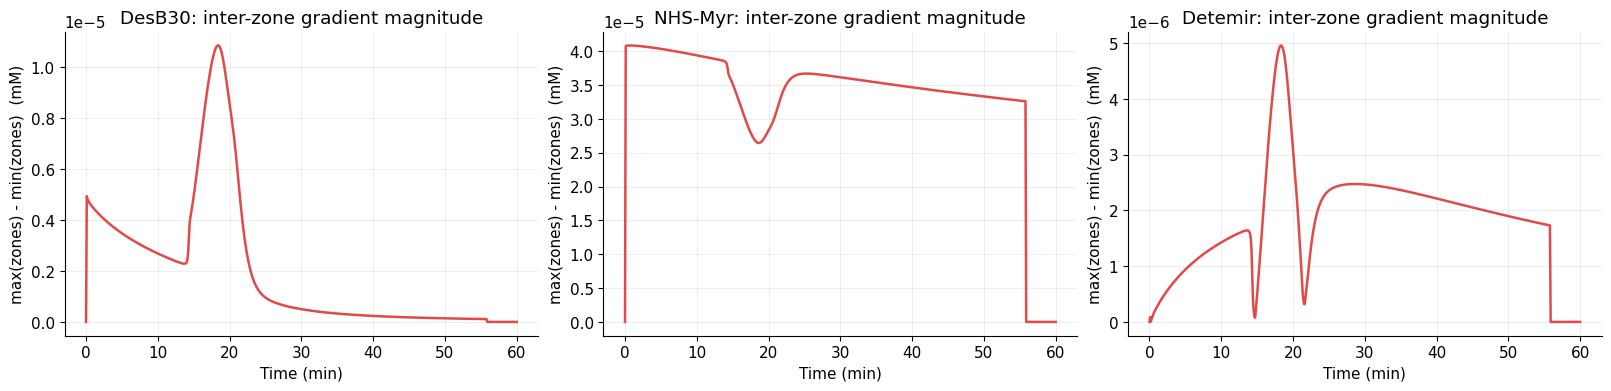

In [5]:
# =====================================================================
# CELL 4b: GRADIENT MAGNITUDE DIAGNOSTIC (validated Q_1->2, Q_2->3) + TIMESCALE COMPARISON
# =====================================================================
tau_12_s = V2_fixed_L / Q12_L_min * 60.0
tau_23_s = V2_fixed_L / Q23_L_min * 60.0
print(f"Zone residence times at the validated flow rates:")
print(f"  tau (Zone1<->Zone2, V2/Q_1->2) = {tau_12_s:.1f} s")
print(f"  tau (Zone2<->Zone3, V2/Q_2->3) < {tau_23_s:.1f} s (Q_2->3 is a LOWER bound, so this is an upper bound on tau)")
print(f"  Reaction timescale (NHS-Myr feed duration)  = {T_FEED_S:.0f} s ({T_FEED_MIN:.1f} min)")
print(f"  Ratio (reaction time / mixing time) ~ {T_FEED_S/max(tau_12_s, tau_23_s):.0f}x -- mixing is not rate-limiting here.")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), constrained_layout=True)
for ax, (name, title) in zip(axes, plot_species):
    idx = REACTIVE_SPECIES.index(name)
    gap = Conc[idx, :, :].max(axis=0) - Conc[idx, :, :].min(axis=0)   # max-min across zones, vs time
    ax.plot(t_min, gap, color='#e34948', linewidth=1.8)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('max(zones) - min(zones)  (mM)')
    ax.set_title(f'{title}: inter-zone gradient magnitude')
    ax.grid(alpha=0.25, linewidth=0.6)
    peak_gap = gap.max()
    peak_scale = np.abs(Conc[idx, :, :]).max()
    print(f"{title}: peak inter-zone gap = {peak_gap:.6f} mM ({100*peak_gap/max(peak_scale,1e-12):.3f}% of the trace's own peak magnitude)")
plt.show()


## Illustrative-only comparison: a genuinely mass-transfer-limited reactor

**Not a validated result** — $Q_{1\to2}=0.05$ L/min and $Q_{2\to3}=0.01$ L/min below are synthetic values,
two to three orders of magnitude slower than anything the titration fit supports, chosen purely to show
what visible axial gradients *would* look like in this same reactor/kinetics if circulation were the
bottleneck instead of reaction. This is shown for contrast and intuition only — it should not be read as
a prediction for the real 160 RPM process.

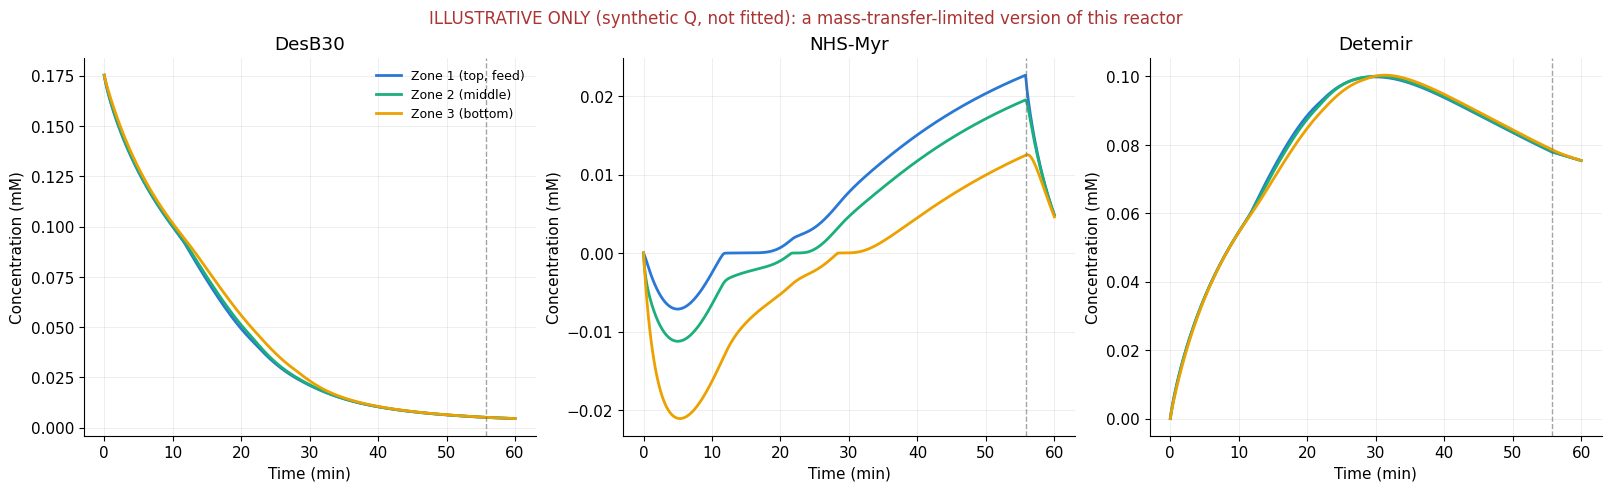

In [6]:
# =====================================================================
# CELL 4c: ILLUSTRATIVE-ONLY -- synthetic slow Q_1->2, Q_2->3 (NOT validated/fitted values)
# =====================================================================
Q12_illustrative = 0.05   # L/min -- synthetic, ~135x slower than the validated Q_1->2
Q23_illustrative = 0.01   # L/min -- synthetic, well below even the 95% lower bound on Q_2->3


def ode_rhs_illustrative(t, yf):
    y = yf.reshape(N_REACTIVE, N_ZONES)
    V1 = V1_of_t(t)
    Vvec = np.array([V1, V2_fixed_L, V3_fixed_L])
    dydt = np.zeros_like(y)
    for j in range(N_ZONES):
        Cj = {name: y[REACTIVE_SPECIES.index(name), j] / Vvec[j] for name in REACTIVE_SPECIES}
        d = reaction_derivs_mM_s(Cj, k, k_quench)
        for name, val_mM_s in d.items():
            dydt[REACTIVE_SPECIES.index(name), j] += val_mM_s * Vvec[j]
    C = y / Vvec[np.newaxis, :]
    exch12 = Q12_illustrative * (C[:, 0] - C[:, 1])
    exch23 = Q23_illustrative * (C[:, 1] - C[:, 2])
    dydt[:, 0] += -exch12
    dydt[:, 1] += +exch12 - exch23
    dydt[:, 2] += +exch23
    dydt[REACTIVE_SPECIES.index('nhs_myr'), 0] += feed_rate_mmol_s_at(t)
    return dydt.flatten()


sol_illustrative = solve_ivp(ode_rhs_illustrative, (0, t_hold_s), y0, method='Radau', rtol=1e-7, atol=1e-10,
                              dense_output=True, events=make_nhs_exhausted_event(1e-4 * moles_nhs_mmol), max_step=30.0)

t_grid_s_ill = np.linspace(sol_illustrative.t[0], sol_illustrative.t[-1], 600)
Y_ill = sol_illustrative.sol(t_grid_s_ill).reshape(N_REACTIVE, N_ZONES, -1)
V1_series_ill = np.array([V1_of_t(ts) for ts in t_grid_s_ill])
Vzone_series_ill = np.stack([V1_series_ill, np.full_like(V1_series_ill, V2_fixed_L), np.full_like(V1_series_ill, V3_fixed_L)])
Conc_ill = Y_ill / Vzone_series_ill[np.newaxis, :, :]
t_min_ill = t_grid_s_ill / 60.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (name, title) in zip(axes, plot_species):
    idx = REACTIVE_SPECIES.index(name)
    for j in range(N_ZONES):
        ax.plot(t_min_ill, Conc_ill[idx, j, :], color=zone_colors[j], linewidth=2, label=zone_labels[j])
    ax.axvline(T_FEED_MIN, color='#666666', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Concentration (mM)')
    ax.set_title(title)
    ax.grid(alpha=0.25, linewidth=0.6)
axes[0].legend(loc='upper right', frameon=False, fontsize=9)
fig.suptitle('ILLUSTRATIVE ONLY (synthetic Q, not fitted): a mass-transfer-limited version of this reactor',
             fontsize=12, color='#a33')
plt.show()


## Endpoint concentrations per compartment and mass-balance check

In [7]:
# =====================================================================
# CELL 5: ENDPOINT SUMMARY TABLE (all 8 reactive species x 3 zones) + MASS BALANCE
# =====================================================================
y_end = sol.y[:, -1].reshape(N_REACTIVE, N_ZONES)
V_end = np.array([V1_of_t(sol.t[-1]), V2_fixed_L, V3_fixed_L])
C_end_mM = y_end / V_end[np.newaxis, :]

table = pd.DataFrame(C_end_mM, index=REACTIVE_SPECIES, columns=['Zone 1 (mM)', 'Zone 2 (mM)', 'Zone 3 (mM)'])
table['Overall (mM)'] = y_end.sum(axis=1) / V_end.sum()
print(f"Endpoint (t = {sol.t[-1]/60.0:.2f} min) concentrations by compartment:\n")
print(table.round(5).to_string())

protein_species = ['desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']
protein_mmol_per_zone = np.array([sum(y_end[REACTIVE_SPECIES.index(s), j] for s in protein_species) for j in range(N_ZONES)])
total_protein_mmol = protein_mmol_per_zone.sum()

print(f"\n{'='*70}")
print("  MASS BALANCE CHECK (protein-bearing species: desb30+detemir+other_DS1+DS2_total+DS3)")
print(f"{'='*70}")
print(f"  Zone 1: {protein_mmol_per_zone[0]:.6f} mmol | Zone 2: {protein_mmol_per_zone[1]:.6f} mmol | "
      f"Zone 3: {protein_mmol_per_zone[2]:.6f} mmol")
print(f"  Total protein (all zones) : {total_protein_mmol:.6f} mmol")
print(f"  Initial DesB30 charge     : {moles_desb30_mmol:.6f} mmol")
print(f"  Ratio (should be ~1.0)    : {total_protein_mmol / moles_desb30_mmol:.6f}")

detemir_total_mmol = sum(y_end[REACTIVE_SPECIES.index('detemir'), j] for j in range(N_ZONES))
yield_pct = detemir_total_mmol / moles_desb30_mmol * 100.0
print(f"\n  Overall Detemir yield (all zones): {yield_pct:.2f}% of charged DesB30")
print(f"  Gly-Myr formed (should be ~0, no glycine dosed in this Stage-2-only scope): "
      f"{sum(y_end[REACTIVE_SPECIES.index('gly_myr'), j] for j in range(N_ZONES)):.2e} mmol")


Endpoint (t = 60.00 min) concentrations by compartment:

           Zone 1 (mM)  Zone 2 (mM)  Zone 3 (mM)  Overall (mM)
nhs_myr        0.00499      0.00499      0.00499       0.00499
desb30         0.00443      0.00443      0.00443       0.00443
detemir        0.07489      0.07489      0.07489       0.07489
other_DS1      0.00238      0.00238      0.00238       0.00238
DS2_total      0.02387      0.02387      0.02387       0.02387
DS3            0.03615      0.03615      0.03615       0.03615
glycine       -0.00000     -0.00000     -0.00000      -0.00000
gly_myr        0.00000      0.00000      0.00000       0.00000

  MASS BALANCE CHECK (protein-bearing species: desb30+detemir+other_DS1+DS2_total+DS3)
  Zone 1: 0.249292 mmol | Zone 2: 0.145787 mmol | Zone 3: 0.145787 mmol
  Total protein (all zones) : 0.540865 mmol
  Initial DesB30 charge     : 0.540865 mmol
  Ratio (should be ~1.0)    : 1.000000

  Overall Detemir yield (all zones): 52.84% of charged DesB30
  Gly-Myr formed (should b

## Known Limitations / Next Steps

- **At the validated flow rates, the 3 compartments are numerically well-mixed for this reaction — this
  is the headline finding, not a footnote.** Zone residence times (5–16 s) are ~200x shorter than the
  reaction timescale (feed alone takes 55.8 min), so the peak inter-zone gradient is a fraction of a
  percent of each species' own trace magnitude (quantified in the gradient-diagnostic cell above). The
  separate illustrative-only panel (synthetic $Q$, clearly labeled, not fitted) exists specifically to
  show what a genuinely mass-transfer-limited version of this reactor would look like, since the
  validated-parameter plot alone would otherwise just look like three overlapping lines with no
  explanation. **Conclusion for this specific process:** the original dual-compartment (and even
  well-mixed) approximation is adequate for myristoylation kinetics at 160 RPM in this vessel; spatial
  resolution matters for the *mixing/titration* dynamics themselves (which happen on the same ~seconds-
  to-minutes timescale it resolves), not for this particular reaction network.
- **The 3-zone split here is a simple equal-height division of this reactor's own liquid column, not
  the impeller-anchored split used in `5L_tank_transfer_mass_3_compartments.ipynb`.** The two notebooks'
  zone boundaries are not directly comparable in absolute height; only the flow rates ($Q_{1\to2}$,
  $Q_{2\to3}$) are carried over.
- **$Q_{2\to3}$ is a 95% confidence lower bound, not a measured value** (see markdown ASSUMPTION above).
  Using it is a deliberate choice to show the most zone-differentiated scenario the titration data does
  not rule out; the real Zone 2/Zone 3 gradient could be much smaller (if the true exchange is faster) —
  it cannot be larger than what is shown here for a given $Q_{1\to2}$, but the *shape* of the gradient at
  much larger $Q_{2\to3}$ would show Zone 2 and Zone 3 nearly merged.
- **Radial homogeneity within each zone** (only axial/zone-to-zone gradients are tracked) and
  **instantaneous local reaction kinetics per zone** (unchanged from the source notebook's own
  assumptions) are carried over without re-validation.
- **Stage 1 and Stage 3 are out of scope**, matching `transfer_mass_5L_pde.ipynb`'s precedent: Stage 1 is
  assumed already well-mixed (supplies the uniform DesB30 initial condition); Stage 3 (glycine quench) is
  not simulated, so `glycine`/`gly_myr` stay at (or near) zero throughout by construction.
- **Fixed compartment topology** (chain, no direct Zone1↔Zone3 exchange) is assumed, matching the
  titration notebook's own validated topology; not tested against alternatives.
- Cross-checked against the original dual-compartment model's Q (2.970 L/min, Section 4 of the source
  notebook) and against `transfer_mass_5L_pde.ipynb`'s domain length (9.35 cm) — both match as expected
  (see the geometry cell's printed cross-checks above).
